In [1]:
import numpy as np
import pandas as pd
import warnings
from datetime import date
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from models import FeedForward, LSTM, Hybrid

warnings.filterwarnings('ignore')

In [2]:
import os
from torch.utils.data import Dataset

def compute_valid_indices(tickers: np.ndarray, seq_len: int) -> np.ndarray:
    """Indices i where window [i-seq_len:i) stays within same ticker segment."""
    t = np.asarray(tickers)
    n = len(t)
    idx = []
    start = 0
    for i in range(1, n + 1):
        if i == n or t[i] != t[i - 1]:
            end = i
            if end - start > seq_len:
                idx.extend(range(start + seq_len, end))
            start = end
    return np.asarray(idx, dtype=np.int32)

class SequenceDataset(Dataset):
    """Lazily yields sliding windows without materializing X_seq in RAM."""
    def __init__(self, X: np.ndarray, y: np.ndarray, tickers: np.ndarray, seq_len: int):
        self.X = torch.from_numpy(X.astype(np.float32, copy=False))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.int64, order='C').copy())
        self.seq_len = seq_len
        self.valid_idx = compute_valid_indices(tickers, seq_len)

    def __len__(self):
        return len(self.valid_idx)

    def __getitem__(self, i):
        idx = self.valid_idx[i]
        x = self.X[idx - self.seq_len + 1: idx + 1]
        y = self.y[idx]
        return x, y
    
class CUDAPrefetchLoader:
    def __init__(self, loader, device, prefetch=4):
        self.loader, self.device, self.prefetch = loader, device, prefetch
        self.stream = torch.cuda.Stream() if device.type == 'cuda' else None

    def __iter__(self):
        if self.stream is None:
            yield from self.loader
            return

        it, cache = iter(self.loader), []
        with torch.cuda.stream(self.stream):
            for _ in range(self.prefetch):
                try:
                    bx, by = next(it)
                except StopIteration:
                    break
                cache.append((
                    bx.to(self.device, dtype=torch.float32, non_blocking=True),
                    by.to(self.device, dtype=torch.long, non_blocking=True)
                ))

        while cache:
            torch.cuda.current_stream().wait_stream(self.stream)
            batch = cache.pop(0)

            try:
                nx, ny = next(it)
                with torch.cuda.stream(self.stream):
                    cache.append((
                        nx.to(self.device, dtype=torch.float32, non_blocking=True),
                        ny.to(self.device, dtype=torch.long, non_blocking=True)
                    ))
            except StopIteration:
                pass
            yield batch
            
    def __len__(self):
        return len(self.loader)

In [3]:
# READ S&P 500 TICKERS FROM TXT
def load_simple_ticker_list(filename='sp500_tickers.txt'):
    """Load tickers from simple text file (one per line)"""
    try:
        with open(filename, 'r') as f:
            tickers = [line.strip() for line in f.readlines() if line.strip()]
        return tickers
    except FileNotFoundError:
        print(f"❌ File {filename} not found.")
        return []

tickers = load_simple_ticker_list('sp500_tickers.txt')

In [4]:
# S&P 500 STOCK PROCESSING WITH LIMITS
import gc

# STOCK LIMIT CONFIGURATION
USE_FULL_DATASET = False  # Set to True when ready for full run
STOCK_LIMIT = 5          # Limit for testing (set to desired number)

# Apply stock limit
if USE_FULL_DATASET:
    processing_tickers = tickers
    print(f"🚀 FULL DATASET MODE: Processing all {len(processing_tickers)} S&P 500 stocks")
else:
    processing_tickers = tickers[:STOCK_LIMIT]
    print(f"🧪 TEST MODE: Processing first {len(processing_tickers)} stocks")

all_data = []
total_tickers = len(processing_tickers)

print("=" * 60)
print(f"🎯 Stocks to process: {total_tickers}")
print("=" * 60)

ticker_to_code = {t: i for i, t in enumerate(processing_tickers)}

# For progress tracking
successful_stocks = 0
failed_stocks = 0

for idx, ticker in enumerate(processing_tickers, 1):
    try:
        features = pd.read_parquet(f'processed_features_cleaned2/{ticker}.parquet')
        features['Ticker'] = np.int16(ticker_to_code[ticker])
        
        features['Target'] = features['Close'].pct_change(periods=4).shift(-4)
        float_cols = features.select_dtypes(include=['float64', 'float32']).columns
        features[float_cols] = features[float_cols].astype(np.float32, copy=False)

        all_data.append(features)
        
        # GARBAGE COLLECTION
        if idx % 25 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"\r🧹 [{idx}/{total_tickers}] Memory cleanup completed" + " " * 30)
            
    except Exception as e:
        print(f"\r❌ [{idx}/{total_tickers}] {ticker}: Error - {str(e)}")
        continue
    
# Combine all data
if all_data:
    ml_data = pd.concat(all_data, ignore_index=True)
    
    print(f"📊 Total samples: {len(ml_data):,}")
    print(f"📈 Stocks: {len(ml_data['Ticker'].unique())}")
    print(f"💾 Memory: {ml_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
else:
    print("\n❌ ERROR: No data processed successfully!")
    ml_data = pd.DataFrame()
    
del all_data
gc.collect()

🧪 TEST MODE: Processing first 5 stocks
🎯 Stocks to process: 5
📊 Total samples: 319,190
📈 Stocks: 5
💾 Memory: 126.0 MB


20

In [5]:
#Device Detection
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon GPU")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using GPU: NVIDIA L4


In [6]:
# DATA PREPARATION FOR PYTORCH
print("📊 PREPARING DATA FOR PYTORCH")
print("=" * 40)

from sklearn.preprocessing import RobustScaler
from typing import Any, Tuple

def prep_training_data(ml_data, sequence_length=16, test_size=0.2,
                        neutral_band: Tuple[float, float] = (0.40, 0.60),   # narrower neutral
                        label_from_train: bool = True
                    ) -> dict[str, Any]:
    """
    Prepare data for PyTorch training
    Args:
        ml_data (pd.DataFrame): Your dataset
        sequence_length (int): Number of days to look back (for LSTM)
        test_size (int): Fraction for testing
    Returns:
        data (dict): With torch float sensors sent to the {device}
    """
    # Separate features and target
    feature_cols = [col for col in ml_data.columns if col not in ['Target', 'Ticker']]    
    ml_data.dropna(inplace=True)
        
    print(f"📋 Input data shape: {ml_data.shape}")
    
    # Per-ticker temporal split
    X_tr, y_tr, t_tr = [], [], []
    X_te, y_te, t_te = [], [], []

    for tic, g in ml_data.groupby('Ticker', sort=False):
        n = len(g)
        if n < 32:  # skip very short segments
            print('skipped short segment')
            continue
        split = int(n * (1 - test_size))
        gtr = g.iloc[:split] # train size
        gte = g.iloc[split:] # test size

        # Train-only thresholds per ticker
        if label_from_train:
            q_low, q_high = neutral_band
            r = gtr['Target'].to_numpy()
            ql = np.quantile(r, q_low)
            qh = np.quantile(r, q_high)

            def label(ret):
                return 2 if ret > qh else (0 if ret < ql else 1)

            ytr = gtr['Target'].map(label).to_numpy(dtype=np.int64)
            yte = gte['Target'].map(label).to_numpy(dtype=np.int64)
        else:
            # Fallback: compute thresholds on each split (not recommended)
            q_low, q_high = neutral_band
            ql_tr, qh_tr = np.quantile(gtr['Target'], q_low), np.quantile(gtr['Target'], q_high)
            ql_te, qh_te = np.quantile(gte['Target'], q_low), np.quantile(gte['Target'], q_high)
            ytr = np.where(gtr['Target'] > qh_tr, 2, np.where(gtr['Target'] < ql_tr, 0, 1)).astype(np.int64)
            yte = np.where(gte['Target'] > qh_te, 2, np.where(gte['Target'] < ql_te, 0, 1)).astype(np.int64)

        X_tr.append(gtr[feature_cols].to_numpy(dtype=np.float32, copy=False))
        y_tr.append(ytr)
        t_tr.append(gtr['Ticker'].to_numpy(dtype=np.int16, copy=False))

        X_te.append(gte[feature_cols].to_numpy(dtype=np.float32, copy=False))
        y_te.append(yte)
        t_te.append(gte['Ticker'].to_numpy(dtype=np.int16, copy=False))
        
    # Concatenate splits
    X_train = np.concatenate(X_tr) if X_tr else np.empty((0, len(feature_cols)), dtype=np.float32)
    y_train = np.concatenate(y_tr) if y_tr else np.empty((0,), dtype=np.int64)
    t_train = np.concatenate(t_tr) if t_tr else np.empty((0,), dtype=np.int16)

    X_test = np.concatenate(X_te) if X_te else np.empty((0, len(feature_cols)), dtype=np.float32)
    y_test = np.concatenate(y_te) if y_te else np.empty((0,), dtype=np.int64)
    t_test = np.concatenate(t_te) if t_te else np.empty((0,), dtype=np.int16)
    
    del ml_data
    gc.collect()

    # --- FIX: Fit scaler ONLY on training data ---
    feature_scaler = RobustScaler()
    X_train = feature_scaler.fit_transform(X_train).astype(np.float32, copy=False)
    X_test = feature_scaler.transform(X_test).astype(np.float32, copy=False)
    
    data = {
        'raw': {
            'X_train': X_train, 'y_train': y_train, 't_train': t_train,
            'X_test': X_test,   'y_test': y_test,   't_test': t_test
        },
        'feature_names': feature_cols,
        'sequence_length': sequence_length
    }
    
    print(f"✅ Regular data - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"✅ Sequence data - built lazily in DataLoader")
    
    del X_train, X_test, y_train, y_test
    gc.collect()
    
    return data

training_data = prep_training_data(
    ml_data,
    sequence_length=16,
    test_size=0.1,
    neutral_band=(1/3, 2/3)
)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 40)

📊 PREPARING DATA FOR PYTORCH


📋 Input data shape: (319167, 88)
✅ Regular data - Train: (287247, 86), Test: (31920, 86)
✅ Sequence data - built lazily in DataLoader


In [7]:

# PYTORCH TRAINING FUNCTIONS AND EXECUTION
from torch import autocast
from torch.utils.data import WeightedRandomSampler

def train_pytorch_model(model, data, epochs, model_type, batch_size, lr):
    """
    Train PyTorch model and track directional accuracy (Supports GPU)
    
    Args:
        model: PyTorch model
        data: Prepared data dictionary  
        model_type: 'regular' or 'sequence'
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
    """
    model = model.to(device).to(dtype=torch.float32)

    # torch.compile can be flaky with cuDNN LSTM; skip for sequence models
    if model_type != 'sequence' and device.type != 'mps':
        try:
            model = torch.compile(model, mode="default", dynamic=True)
        except Exception as e:
            print("compile skipped:", e)
    
    # Build datasets on CPU
    if model_type == 'sequence':
        seq_len = data.get('sequence_length', 16)
        Xtr = data['raw']['X_train']; ytr = data['raw']['y_train']; ttr = data['raw']['t_train']
        Xte = data['raw']['X_test'];  yte = data['raw']['y_test'];  tte = data['raw']['t_test']
        train_dataset = SequenceDataset(Xtr, ytr, ttr, seq_len)
        test_dataset  = SequenceDataset(Xte, yte, tte, seq_len)
        train_labels_np = train_dataset.y[train_dataset.valid_idx].cpu().numpy()
    else:
        Xtr = torch.from_numpy(data['raw']['X_train']).to(dtype=torch.float32)
        ytr = torch.from_numpy(data['raw']['y_train'].astype(np.int64, copy=False))  # CrossEntropy needs long
        Xte = torch.from_numpy(data['raw']['X_test']).to(dtype=torch.float32)
        yte = torch.from_numpy(data['raw']['y_test'].astype(np.int64, copy=False))

        train_dataset = TensorDataset(Xtr, ytr)
        test_dataset  = TensorDataset(Xte, yte)
        train_labels_np = ytr.cpu().numpy()
        
    # --- Class weights (handle class imbalance; encourage Neutral predictions) ---
    class_counts = np.bincount(train_labels_np, minlength=3)
    eps = 1e-6
    inv_freq = class_counts.sum() / (class_counts + eps)
    class_weights = inv_freq / inv_freq.mean()
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    # --- Weighted sampling to balance mini-batches ---
    sample_weights = class_weights[train_labels_np].astype(np.float64)
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double).tolist(),
        num_samples=len(sample_weights),
        replacement=True
    )
    
    # DataLoaders: pin memory + workers to stream batches
    if device.type == 'cuda':
        num_workers = max(1, os.cpu_count() // 2)
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            drop_last=True, pin_memory=(device.type=='cuda'), num_workers=num_workers,
            persistent_workers=(num_workers>0), prefetch_factor=2
        )
        test_loader = DataLoader(
            test_dataset, batch_size=batch_size, shuffle=False,
            pin_memory=(device.type=='cuda'), num_workers=num_workers,
            persistent_workers=(num_workers>0), prefetch_factor=2
        )
        
        train_loader = CUDAPrefetchLoader(train_loader, device, prefetch=4)
        test_loader  = CUDAPrefetchLoader(test_loader, device, prefetch=2)
    else:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, drop_last=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    loss_fn = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,
        div_factor=25,
        final_div_factor=1e4,
        anneal_strategy='cos'
    )
    
    train_losses, test_losses, directional_accuracies = [], [], []
    for epoch in range(epochs):
        nb = (device.type == 'cuda')
        # Training
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            optimizer.zero_grad()
            x = x.to(device, non_blocking=nb)
            y = y.to(device, non_blocking=nb)

            outputs = model(x)
            loss = loss_fn(outputs, y)
            loss.backward()
                
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += float(loss.detach().cpu())
            
        # Testing
        model.eval()
        test_loss, correct_predictions, total_predictions = 0.0, 0, 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device, non_blocking=nb)
                y = y.to(device, non_blocking=nb)
                
                outputs = model(x)
                loss = loss_fn(outputs, y)

                test_loss += loss.item() * y.size(0)
                preds = outputs.argmax(1)
                total_predictions += y.size(0)
                correct_predictions += (preds == y).sum().item()
        
        accuracy = 100 * correct_predictions / total_predictions
        avg_test_loss = test_loss / total_predictions
        avg_train_loss = train_loss / len(train_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        directional_accuracies.append(accuracy)

        print(f'Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}, Accuracy: {accuracy:.1f}%, Lr: {optimizer.param_groups[0]["lr"]:.3e}')
    
    # Final evaluation
    model.eval()
    predictions, actuals = [], []
    prob_down, prob_neutral, prob_up = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            
            x = x.to(device, non_blocking=nb)
            y = y.to(device, non_blocking=nb)

            outputs = model(x)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            
            predictions.extend(preds.cpu().numpy().tolist())
            actuals.extend(y.cpu().numpy().tolist())
            prob_down.extend(probs[:, 0].cpu().numpy().tolist())
            prob_neutral.extend(probs[:, 1].cpu().numpy().tolist())
            prob_up.extend(probs[:, 2].cpu().numpy().tolist())

    predictions_np = np.array(predictions)
    actuals_np = np.array(actuals)
    
    # ✅ DEBUG: Check what we actually got
    print(f"🔍 Debug - Unique predictions: {np.unique(predictions_np)}")
    print(f"🔍 Debug - Unique actuals: {np.unique(actuals_np)}")
    print(f"🔍 Debug - Predictions shape: {predictions_np.shape}")
    print(f"🔍 Debug - Actuals shape: {actuals_np.shape}")
    
    # For classification, we need different metrics
    from sklearn.metrics import classification_report, accuracy_score, f1_score
    
    accuracy_final = accuracy_score(actuals_np, predictions_np) * 100
    f1_weighted = f1_score(actuals_np, predictions_np, average='weighted')
    
    print(f"📊 Final Metrics - Accuracy: {accuracy_final:.2f}%, F1-Score: {f1_weighted:.4f}")
    print("\n📋 Classification Report:")
    print(classification_report(actuals_np, predictions_np, labels=[0,1,2], target_names=['Down', 'Neutral', 'Up']))
    
    if USE_FULL_DATASET:
            torch.save(model.state_dict(), f'models_full_dataset/{model.__class__.__name__.lower()}_f.pth')
    else:
        torch.save(model.state_dict(), f'models_limited/{model.__class__.__name__.lower()}_l.pth')
    
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'directional_accuracies': directional_accuracies,
        'predictions': predictions,
        'actuals': actuals_np.tolist(),
        'probs': { 'down': prob_down, 'neutral': prob_neutral, 'up': prob_up },
        'metrics': {'accuracy': accuracy_final, 'f1_score': f1_weighted}
    }

In [8]:
# TRAIN ALL MODELS
print(f"🔥 TRAINING NEURAL NETWORKS ON {device}")
print("=" * 50)

if USE_FULL_DATASET:
    global_epochs = 12
    global_batch_size = 2048     # Larger batches for efficiency
    global_lr = 0.005          # Lower learning rate for stability
else:
    global_epochs = 10
    global_batch_size = 256
    global_lr = 0.001
    
results = {}
# 2. Train LSTM Network
print("\n2️⃣ TRAINING LSTM NETWORK")
print("-" * 25)
lstm_model = LSTM(input_features=len(training_data['feature_names'])).to(device)
results['LSTM'] = train_pytorch_model(
    lstm_model, training_data, model_type='sequence', epochs=global_epochs,
    batch_size=global_batch_size,
    lr=global_lr
)

# 3. Train Hybrid Network
print("\n3️⃣ TRAINING HYBRID CNN-LSTM NETWORK") 
print("-" * 35)
hybrid_model = Hybrid(input_features=len(training_data['feature_names'])).to(device)
results['Hybrid'] = train_pytorch_model(
    hybrid_model, training_data, model_type='sequence', epochs=global_epochs,
    batch_size=global_batch_size,
    lr=global_lr
)
# 1. Train Feed-Forward Neural Network
print("\n1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK")
print("-" * 45)
ff_model = FeedForward(input_features=len(training_data['feature_names'])).to(device)
results['FeedForward'] = train_pytorch_model(
    ff_model, training_data, model_type='regular', epochs=global_epochs,
    batch_size=global_batch_size,
    lr=global_lr
)

print("\n✅ PyTorch GPU Training Complete!")
print("=" * 50)

🔥 TRAINING NEURAL NETWORKS ON cuda

2️⃣ TRAINING LSTM NETWORK
-------------------------
Epoch   0: Train Loss: 1.072874, Test Loss: 1.081606, Accuracy: 38.9%, Lr: 7.605e-04
Epoch   1: Train Loss: 1.064711, Test Loss: 1.076551, Accuracy: 39.2%, Lr: 9.915e-04
Epoch   2: Train Loss: 1.060861, Test Loss: 1.077296, Accuracy: 39.4%, Lr: 9.250e-04
Epoch   3: Train Loss: 1.057405, Test Loss: 1.077831, Accuracy: 38.8%, Lr: 8.012e-04
Epoch   4: Train Loss: 1.050024, Test Loss: 1.084939, Accuracy: 38.6%, Lr: 6.367e-04
Epoch   5: Train Loss: 1.028504, Test Loss: 1.102631, Accuracy: 38.1%, Lr: 4.537e-04
Epoch   6: Train Loss: 0.976405, Test Loss: 1.162507, Accuracy: 37.9%, Lr: 2.770e-04
Epoch   7: Train Loss: 0.903093, Test Loss: 1.233544, Accuracy: 37.2%, Lr: 1.304e-04
Epoch   8: Train Loss: 0.840935, Test Loss: 1.311903, Accuracy: 37.6%, Lr: 3.371e-05
Epoch   9: Train Loss: 0.808389, Test Loss: 1.353630, Accuracy: 37.6%, Lr: 4.027e-09
🔍 Debug - Unique predictions: [0 1 2]
🔍 Debug - Unique actuals

Exception in thread Thread-13 (_pin_memory_loop):
Traceback (most recent call last):
  File "/opt/python/3.10/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/victor_mac/repos/stock-robot/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/python/3.10/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/home/victor_mac/repos/stock-robot/.venv/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/victor_mac/repos/stock-robot/.venv/lib/python3.10/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/opt/python/3.10/lib/python3.10/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
  File "/home/victor_mac/repos/stock-robot/.venv/lib

KeyboardInterrupt: 

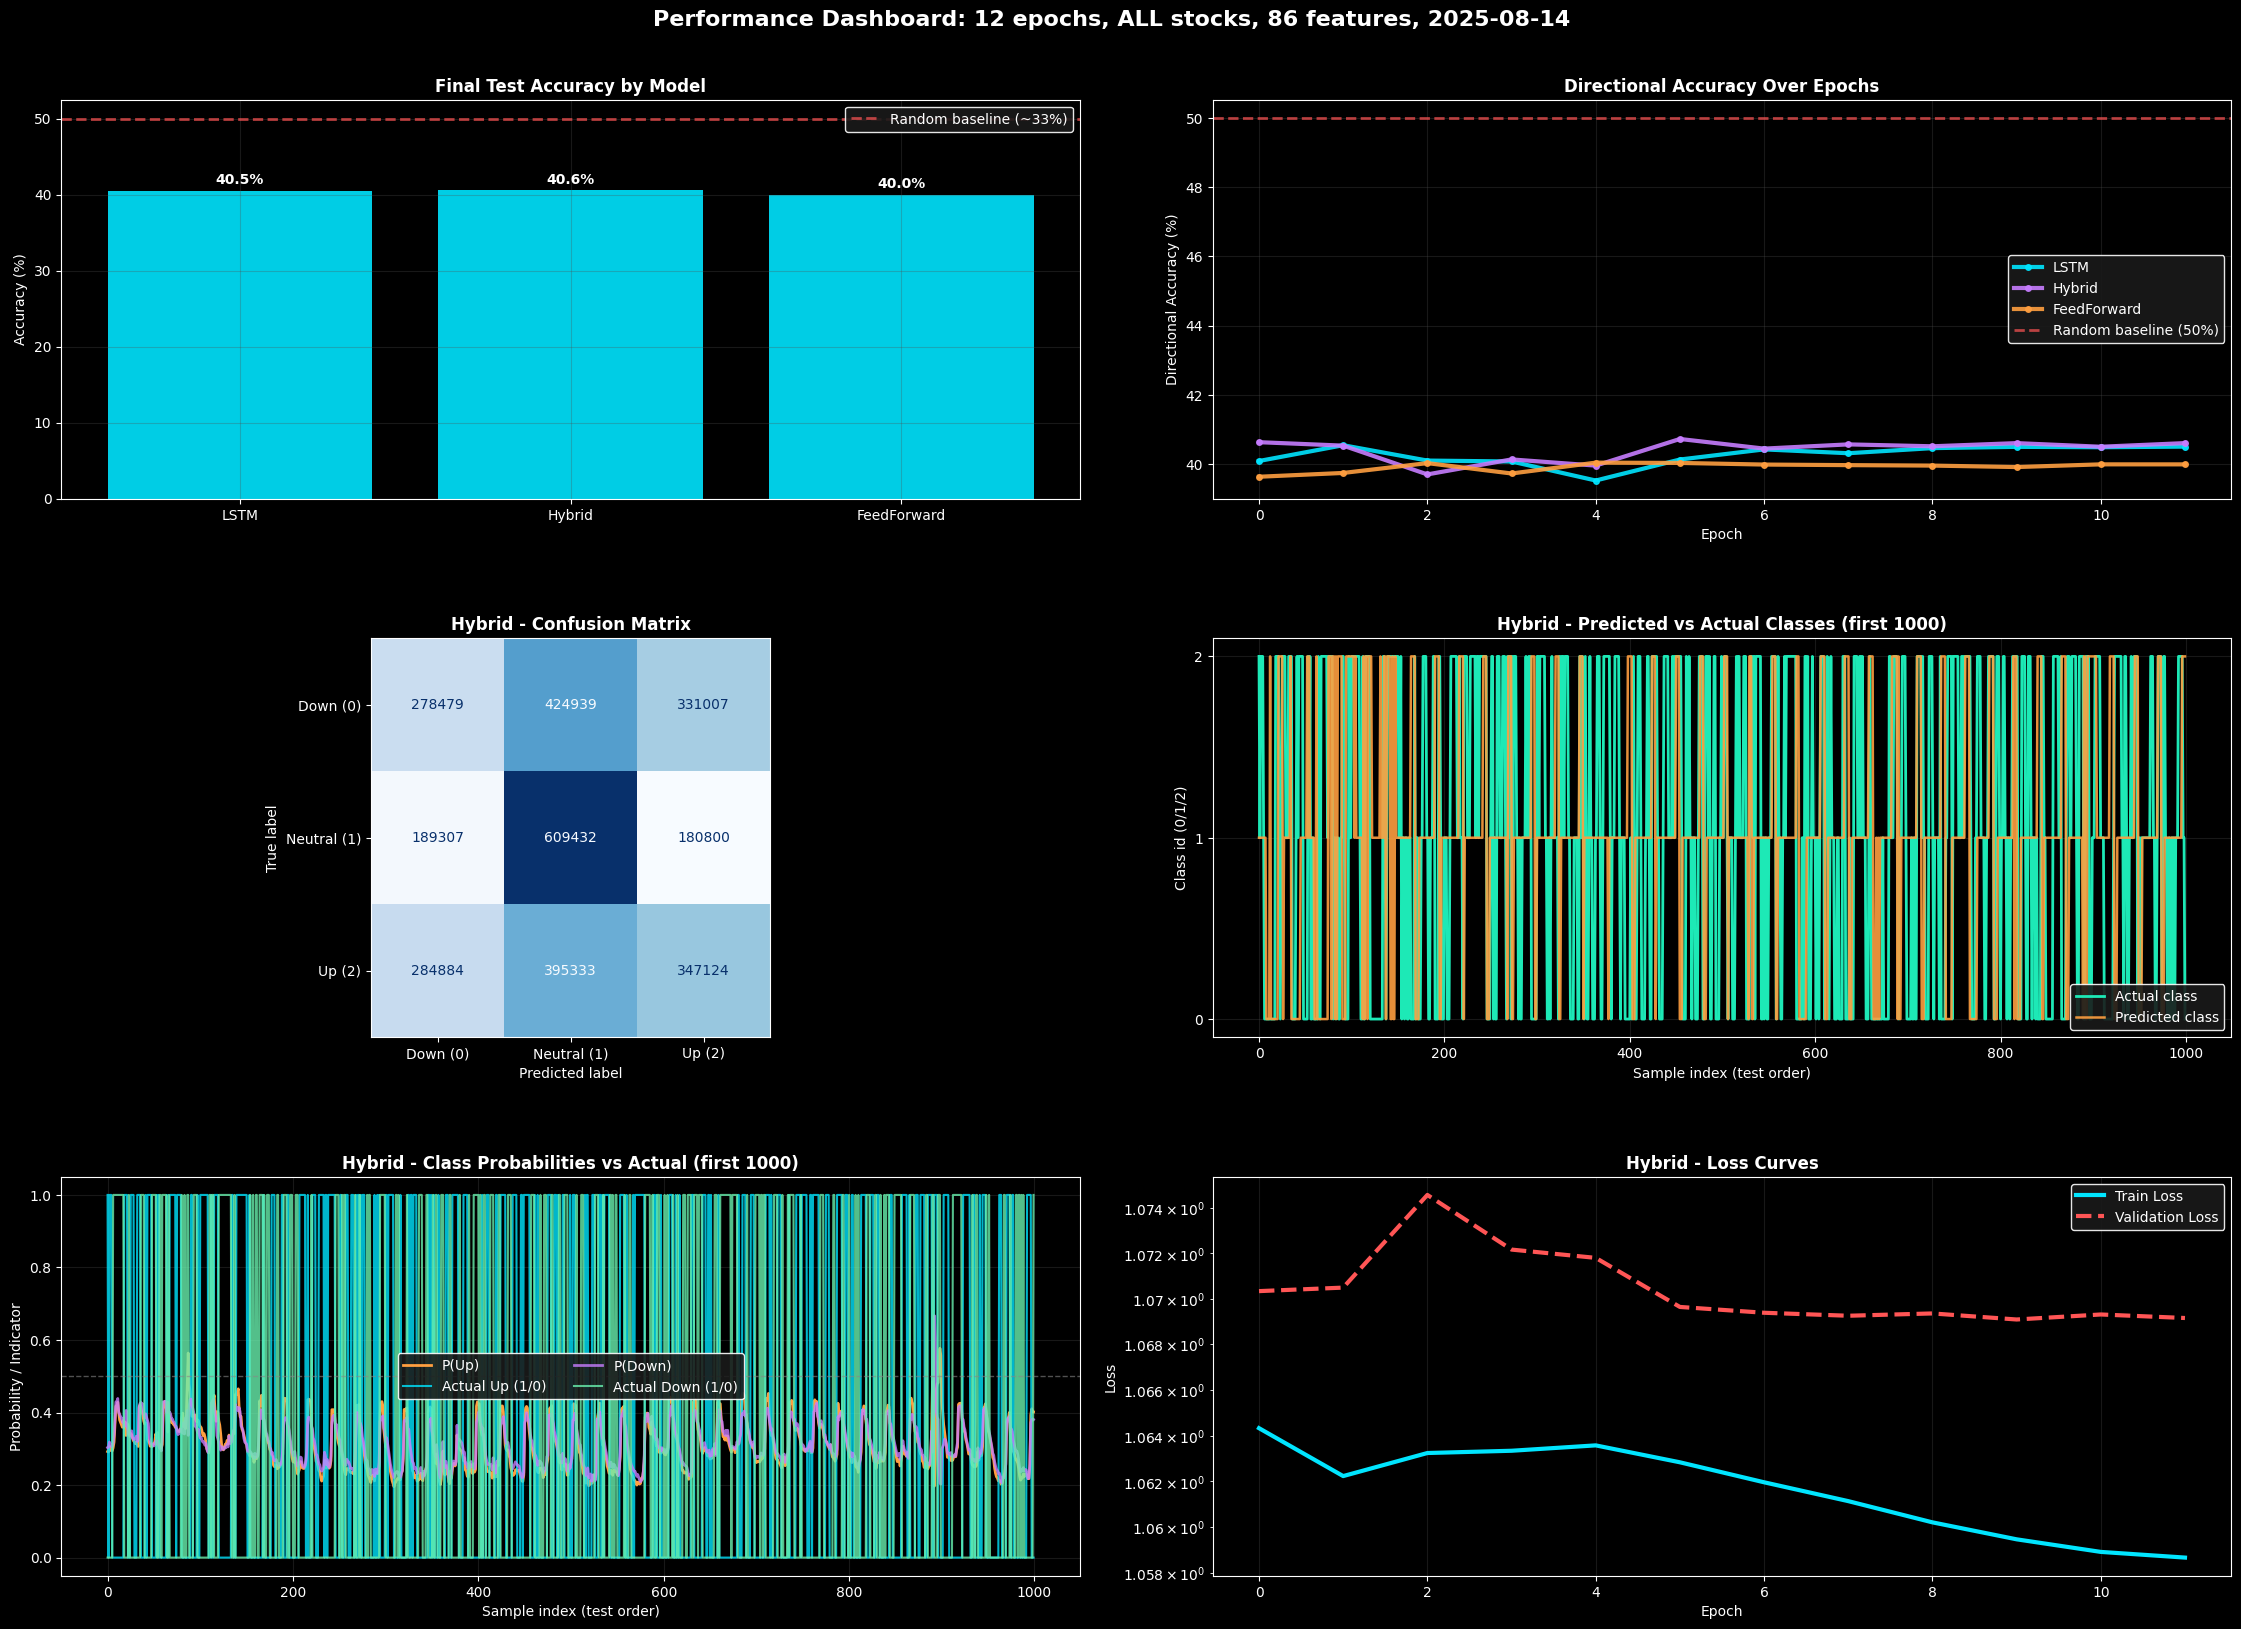

In [ ]:
# PREDICTIONS VS ACTUALS VISUALIZATION (Dark Mode)

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure output dir exists
os.makedirs('models_results', exist_ok=True)

# Set dark theme for plots with TRUE BLACK backgrounds
plt.style.use('dark_background')
matplotlib.rcParams.update({
    'figure.facecolor': '#000000',      # Pure black
    'axes.facecolor': '#000000',        # Pure black
    'savefig.facecolor': '#000000',     # Pure black
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': 'white',
    'grid.color': '#404040',
    'axes.spines.bottom': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True
})

# Bright colors that pop against pure black
dark_colors = {
    'blue': '#00E5FF', 'purple': '#C77DFF', 'orange': '#FF9F40',
    'red': '#FF5555', 'coral': '#FF8A80', 'teal': '#1DE9B6',
    'yellow': '#FFEB3B', 'green': '#69F0AE'
}
colors_cycle = [dark_colors['blue'], dark_colors['purple'], dark_colors['orange'],
                dark_colors['teal'], dark_colors['coral'], dark_colors['yellow']]

# Collect model names and final accuracies
models_list = list(results.keys())
final_accuracies = {m: results[m]['metrics']['accuracy'] for m in models_list}
best_model = max(final_accuracies, key=lambda m: final_accuracies[m])

# Choose a model to visualize in detail (best by accuracy by default)
viz_name = best_model
preds = np.array(results[viz_name]['predictions'])
acts = np.array(results[viz_name]['actuals'])
probs = results[viz_name]['probs']
prob_up = np.array(probs['up'])
prob_down = np.array(probs['down'])
prob_neutral = np.array(probs['neutral'])
N = min(1000, len(acts))  # limit for readability

fig = plt.figure(figsize=(28, 18), facecolor='#000000')
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

fig.suptitle(
    f'Performance Dashboard: {global_epochs} epochs, {STOCK_LIMIT if not USE_FULL_DATASET else "ALL"} stocks, {len(training_data["feature_names"])} features, {date.today()}',
    fontsize=16, fontweight='bold', color='white'
)

# 1) Final Accuracy by Model (bar chart)
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#000000')
x = np.arange(len(models_list))
acc_vals = [final_accuracies[m] for m in models_list]
bars = ax1.bar(x, acc_vals, color=dark_colors['blue'], alpha=0.9)
for i, b in enumerate(bars):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height()+0.5, f'{acc_vals[i]:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.axhline(50, color=dark_colors['red'], linestyle='--', alpha=0.7, linewidth=2, label='Random baseline (~33%)')
ax1.set_title('Final Test Accuracy by Model', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list)
ax1.grid(True, alpha=0.3, color='#505050')
ax1.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')

# 2) Directional Accuracy Over Epochs (all models)
ax2 = fig.add_subplot(gs[0, 2:])
ax2.set_facecolor('#000000')
for i, m in enumerate(models_list):
    if 'directional_accuracies' in results[m]:
        da = results[m]['directional_accuracies']
        ax2.plot(range(len(da)), da, label=m, linewidth=3, marker='o', markersize=4, alpha=0.9,
                 color=colors_cycle[i % len(colors_cycle)])
ax2.axhline(50, color=dark_colors['red'], linestyle='--', alpha=0.7, linewidth=2, label='Random baseline (50%)')
ax2.set_title('Directional Accuracy Over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Directional Accuracy (%)')
ax2.grid(True, alpha=0.3, color='#505050')
ax2.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')

# 3) Confusion Matrix (best model)
ax3 = fig.add_subplot(gs[1, :2])
cm = confusion_matrix(acts, preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Neutral (1)', 'Up (2)'])
disp.plot(ax=ax3, cmap='Blues', colorbar=False, values_format='d')
ax3.set_title(f'{viz_name} - Confusion Matrix', fontweight='bold')
for spine in ax3.spines.values():
    spine.set_edgecolor('white')

# 4) Predicted class vs Actual class (line)
ax4 = fig.add_subplot(gs[1, 2:])
ax4.set_facecolor('#000000')
ax4.plot(range(N), acts[:N], label='Actual class', lw=2, color=dark_colors['teal'])
ax4.plot(range(N), preds[:N], label='Predicted class', lw=1.8, alpha=0.9, color=dark_colors['orange'])
ax4.set_title(f'{viz_name} - Predicted vs Actual Classes (first {N})', fontweight='bold')
ax4.set_xlabel('Sample index (test order)')
ax4.set_ylabel('Class id (0/1/2)')
ax4.set_yticks([0, 1, 2])
ax4.grid(True, alpha=0.3, color='#505050')
ax4.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')

# 5) Class Probabilities vs Actual indicator (best model)
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor('#000000')
actual_up = (acts[:N] == 2).astype(int)
actual_down = (acts[:N] == 0).astype(int)
ax5.plot(range(N), prob_up[:N], label='P(Up)', color=dark_colors['orange'], lw=2)
ax5.plot(range(N), actual_up, label='Actual Up (1/0)', color=dark_colors['blue'], lw=1.5, alpha=0.8)
ax5.plot(range(N), prob_down[:N], label='P(Down)', color=dark_colors['purple'], lw=2, alpha=0.8)
ax5.plot(range(N), actual_down, label='Actual Down (1/0)', color=dark_colors['green'], lw=1.5, alpha=0.8)
ax5.axhline(0.5, color='#888', linestyle='--', alpha=0.6, linewidth=1)
ax5.set_title(f'{viz_name} - Class Probabilities vs Actual (first {N})', fontweight='bold')
ax5.set_xlabel('Sample index (test order)')
ax5.set_ylabel('Probability / Indicator')
ax5.set_ylim(-0.05, 1.05)
ax5.grid(True, alpha=0.3, color='#505050')
ax5.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white', ncol=2)

# 6) Loss Curves (best model)
ax6 = fig.add_subplot(gs[2, 2:])
ax6.set_facecolor('#000000')
train_losses = results[viz_name]['train_losses']
test_losses = results[viz_name]['test_losses']
ax6.plot(range(len(train_losses)), train_losses, label='Train Loss', color=dark_colors['blue'], lw=3)
ax6.plot(range(len(test_losses)), test_losses, label='Validation Loss', color=dark_colors['red'], lw=3, linestyle='--')
ax6.set_title(f'{viz_name} - Loss Curves', fontweight='bold')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Loss')
ax6.grid(True, alpha=0.3, color='#505050')
ax6.legend(framealpha=0.9, facecolor='#1a1a1a', edgecolor='white')
ax6.set_yscale('log')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
save_path = f'models_results/{date.today().strftime("%Y-%m-%d_%H-%M")}_{global_epochs}e_{"500" if USE_FULL_DATASET else STOCK_LIMIT}s_pred-vs-actual.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()